CNN Music Classifer Model

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path
%cd /content/drive/MyDrive/
Path.cwd()

/content/drive/MyDrive


PosixPath('/content/drive/MyDrive')

In [7]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import librosa
from pathlib import Path

# Sklean
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# TensorFlow
import tensorflow as tf
from tensorflow import keras
from keras import layers, optimizers, regularizers, callbacks, models

In [4]:
# Load in Train, Test, and Val Datasets
train_ds = np.load('CNN_Music_Datasets/train.npz')
test_ds = np.load('CNN_Music_Datasets/test.npz')
val_ds = np.load('CNN_Music_Datasets/val.npz')

In [5]:
# Separate Spectrograms from Labels
X_train = train_ds['X']
y_train = train_ds['y']

X_val = val_ds['X']
y_val = val_ds['y']

X_test = test_ds['X']
y_test = test_ds['y']

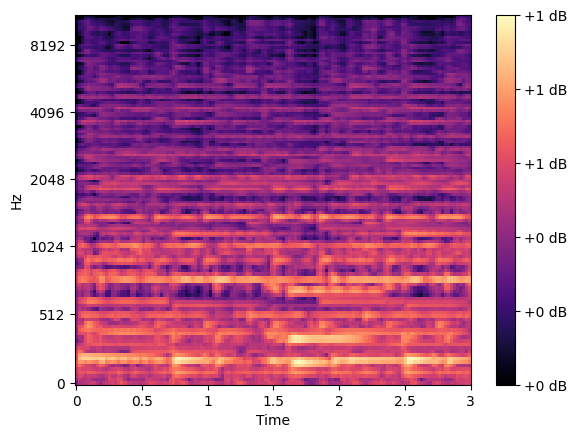

In [6]:
# Plot Mel Spectrogram to ensure proper data
librosa.display.specshow(data=X_train[0], y_axis='mel', x_axis='time')
plt.colorbar(format='%+2.0f dB')
plt.show()

In [7]:
# Check that shapes are correct for CNN
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(15519, 128, 130)
(1926, 128, 130)
(1955, 128, 130)


In [8]:
# Add extra dimension for mono channel for CNN
X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(15519, 128, 130, 1)
(1926, 128, 130, 1)
(1955, 128, 130, 1)


In [9]:
# Save input shape for model
input_shape = X_train.shape[1:]
print(input_shape)

(128, 130, 1)


### Visualization Tools

In [10]:
def plot_history(hist):
    """Plots the accuracy and loss for a model over the course of all epochs

    Parameters:
        hist (keras history object): The recorded history of model.fit() to be plotted
    """
    fig, axs = plt.subplots(2, 1, figsize=(8,7))
    fig.tight_layout(pad=2)

    # Accuracy subplot
    axs[0].plot(hist.history['accuracy'], c='navy', label="Training Accuracy")
    axs[0].plot(hist.history["val_accuracy"], c='orange', label="Validation Accuracy")
    axs[0].set_ylabel("Accuracy")
    axs[0].legend(loc="lower right")
    axs[0].set_title("Accuracy")

    # Error subplot
    axs[1].plot(hist.history["loss"], c='navy', label="Training Loss")
    axs[1].plot(hist.history["val_loss"], c='orange', label="Validation Loss")
    axs[1].set_ylabel("Loss")
    axs[1].set_xlabel("Epochs")
    axs[1].legend(loc="upper right")
    axs[1].set_title("Loss")

    plt.show()

In [ ]:
# Confusion Matrix

GENRE_LABELS = [
    "blues",
    "classical",
    "country",
    "disco",
    "hiphop",
    "jazz",
    "metal",
    "pop",
    "reggae",
    "rock",
]

def confusion_matrix_plot(model, X_test, y_test):

  cmd = ConfusionMatrixDisplay.from_predictions(
      y_test,
      model.predict(X_test).argmax(axis=1),
      cmap="magma",
      display_labels=GENRE_LABELS,
      xticks_rotation=45,)
  plt.show()

### Callbacks and Preprocessing for Layers

In [12]:
import json
import os

class SaveMetricsCallback(keras.callbacks.Callback):
  def __init__(self, filename="metrics.json"):
    super(SaveMetricsCallback, self).__init__()
    self.filename = filename
    self.history = []

    # Ensure the directory exists
    directory = os.path.dirname(self.filename)
    if directory and not os.path.exists(directory):
        os.makedirs(directory, exist_ok=True)

    # Load existing history if the file exists
    if os.path.exists(self.filename) and os.path.getsize(self.filename) > 0:
      try:
        with open(self.filename, 'r') as f:
          self.history = json.load(f)
      except json.JSONDecodeError:
        # Handle cases where the file is empty or corrupted JSON
        print(f"Warning: Could not decode JSON from {self.filename}. Starting with empty history.")
        self.history = []

  def on_epoch_end(self, epoch, logs=None):
    logs = logs or {}
    entry = {"epoch": len(self.history) + epoch, **logs}
    self.history.append(entry)

  def on_train_end(self, logs=None):
    # Save the complete history to the file at the end of training
    with open(self.filename, 'w') as f:
      json.dump(self.history, f, indent=2)

In [6]:
# Log Dir for Model Checkpoint 

log_dir = Path("/Users/wileyjones/Desktop/CS467/CNN_Music_Classifier/src/music_classifier/model/logs")

# Create a callback for early stopping

early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    min_delta=0,
    restore_best_weights=True,
    verbose=1,
    mode='min')

# Learning Rate Scheduler

lr_scheduler = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

# Better Preprocessing layer for audio files

preprocessing_layers = keras.Sequential([
    # 1. Random Translation: Slighly shifts the audio in time (X-axis)
    layers.RandomTranslation(height_factor=0, width_factor=0.1, fill_mode='constant'),

    # 2. Gaussian Noise: Forces the model to ignore background static
    layers.GaussianNoise(0.05)
])

NameError: name 'callbacks' is not defined

In [14]:
class SpecAugment(layers.Layer):
    """
    SpecAugmentation that removes parts of frequency bands to
    help fight overfitting.
    """
    def __init__(self, freq_mask_param=15, time_mask_param=15, **kwargs):
        super().__init__(**kwargs)
        self.freq_mask_param = freq_mask_param
        self.time_mask_param = time_mask_param

    def call(self, x, training=None):
        if not training:
            return x   # no-op at inference time

        shape = tf.shape(x)
        batch, time_steps, freq_bins, channels = shape[0], shape[1], shape[2], shape[3]

        # ── Frequency mask ───────────────────────────────────────────────────
        f  = tf.random.uniform((), 0, self.freq_mask_param, dtype=tf.int32)
        f0 = tf.random.uniform((), 0, freq_bins - f,        dtype=tf.int32)
        freq_mask = tf.concat([
            tf.ones ([batch, time_steps, f0,             channels]),
            tf.zeros([batch, time_steps, f,              channels]),
            tf.ones ([batch, time_steps, freq_bins-f0-f, channels])
        ], axis=2)
        x = x * freq_mask

        # ── Time mask ────────────────────────────────────────────────────────
        t  = tf.random.uniform((), 0, self.time_mask_param, dtype=tf.int32)
        t0 = tf.random.uniform((), 0, time_steps - t,       dtype=tf.int32)
        time_mask = tf.concat([
            tf.ones ([batch, t0,              freq_bins, channels]),
            tf.zeros([batch, t,               freq_bins, channels]),
            tf.ones ([batch, time_steps-t0-t, freq_bins, channels])
        ], axis=1)
        x = x * time_mask

        return x

    def get_config(self):
        config = super().get_config()
        config.update({"freq_mask_param": self.freq_mask_param,
                        "time_mask_param": self.time_mask_param})
        return config

### Full Dataset Models

Full GTZAN/FMA dataset with an additional 999 audio files added.

## Model 7

In [30]:
# Model Version 7
# Back to previous best fitting model with expanded dataset

# Define the L2 strength
l2_strength = 0.001

# Model Version 7
CNN_7_input = layers.Input(shape=input_shape, name="Mel_Spec")

# Preprocessing
x = preprocessing_layers(CNN_7_input)
x = SpecAugment(freq_mask_param=15, time_mask_param=15)(x)

# Layer One
x = layers.Conv2D(32, kernel_size=(3, 3), activation="elu",
                  kernel_regularizer=regularizers.l2(l2_strength))(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPool2D(pool_size=(2, 2))(x)
x = layers.Dropout(0.2)(x)

# Layer Two
x = layers.Conv2D(64, kernel_size=(3,3), activation="elu",
                  kernel_regularizer=regularizers.l2(l2_strength))(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPool2D(pool_size=(2, 2))(x)
x = layers.Dropout(0.2)(x)

# Layer Three
x = layers.Conv2D(64, kernel_size=(3,3), activation="elu",
                  kernel_regularizer=regularizers.l2(l2_strength))(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPool2D(pool_size=(2, 2))(x)
x = layers.Dropout(0.2)(x)

# Flatten out to send through dense layers
x = layers.Flatten()(x)

# Dense Hidden Layer
x = layers.Dense(128, activation="elu",
                 kernel_regularizer=regularizers.l2(l2_strength))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

# Final classification
CNN_7_output = layers.Dense(10, activation="softmax", name="Output")(x)

CNN_7 = keras.Model(CNN_7_input, CNN_7_output, name='CNN_7')
CNN_7.summary()

Model: "CNN_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Mel_Spec (InputLayer)           │ (None, 128, 130, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 128, 130, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spec_augment_3 (SpecAugment)    │ (None, 128, 130, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 126, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 126, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 63, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 63, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 61, 62, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 61, 62, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 30, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 30, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 29, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 28, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,663,946 (6.35 MB)

 Trainable params: 1,663,370 (6.35 MB)

 Non-trainable params: 576 (2.25 KB)

In [ ]:
CNN_7.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy",
             tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3)]
)

# 3. Define the checkpoint with the new version
checkpoint = callbacks.ModelCheckpoint(
    filepath=os.path.join(log_dir,
        f'best_model_v7_epoc_{{epoch:02d}}_val_{{val_loss:.2f}}.keras'),
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

In [ ]:
save_metrics_callback_cnn7 = SaveMetricsCallback(
    filename='CNN_Music_Logs/cnn7_metrics.json')

hist_7 = CNN_7.fit(
    X_train,
    y_train,
    epochs=100,
    validation_data=(X_val, y_val),
    verbose=1,
    callbacks=[save_metrics_callback_cnn7,
               early_stopping,
               checkpoint,
               lr_scheduler]
)

Epoch 1/100
485/485 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.2949 - loss: 2.5819 - sparse_top_k_categorical_accuracy: 0.6219
Epoch 1: val_loss improved from None to 10.37959, saving model to CNN_Music_Logs/best_model_v7_epoc_01_val_10.38.keras

Epoch 1: finished saving model to CNN_Music_Logs/best_model_v7_epoc_01_val_10.38.keras
485/485 ━━━━━━━━━━━━━━━━━━━━ 28s 49ms/step - accuracy: 0.3704 - loss: 2.2640 - sparse_top_k_categorical_accuracy: 0.7216 - val_accuracy: 0.1038 - val_loss: 10.3796 - val_sparse_top_k_categorical_accuracy: 0.3458 - learning_rate: 0.0010
Epoch 2/100
485/485 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4714 - loss: 1.8963 - sparse_top_k_categorical_accuracy: 0.8224
Epoch 2: val_loss improved from 10.37959 to 5.03533, saving model to CNN_Music_Logs/best_model_v7_epoc_02_val_5.04.keras

Epoch 2: finished saving model to CNN_Music_Logs/best_model_v7_epoc_02_val_5.04.keras
485/485 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.4839 - loss: 1.8718 - sparse

## Results of model 7

With the added data, the model is struggling with underfitting a bit. The heavy regularization from the previous models might be too much. Next step is to strip back regularization and see if the model needs to be expanded to better fit the data.

## Model 8

In [44]:
CNN_8_input = layers.Input(shape=input_shape, name="Mel_Spec")

# Layer One
x = layers.Conv2D(32, kernel_size=(3, 3), activation="elu",
                  padding="same")(CNN_8_input)
x = layers.BatchNormalization()(x)
x = layers.MaxPool2D(pool_size=(2, 2))(x)

# Layer Two
x = layers.Conv2D(64, kernel_size=(3,3), activation="elu",
                  padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPool2D(pool_size=(2, 2))(x)

# Layer Three
x = layers.Conv2D(64, kernel_size=(3,3), activation="elu",
                  padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPool2D(pool_size=(2, 2))(x)

# Flatten out to send through dense layers
x = layers.Flatten()(x)

# Dense Hidden Layer
x = layers.Dense(128, activation="elu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

# Final classification
CNN_8_output = layers.Dense(10, activation="softmax", name="Output")(x)

CNN_8 = keras.Model(CNN_8_input, CNN_8_output, name='CNN_8')
CNN_8.summary()

Model: "CNN_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Mel_Spec (InputLayer)           │ (None, 128, 130, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 128, 130, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 128, 130, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 64, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 64, 65, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 64, 65, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,155,466 (8.22 MB)

 Trainable params: 2,154,890 (8.22 MB)

 Non-trainable params: 576 (2.25 KB)

In [45]:
CNN_8.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy",
             tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3)]
)

In [ ]:
# Update callbacks for overfitting test run

# Define the checkpoint with the new version
checkpoint = callbacks.ModelCheckpoint(
    filepath=os.path.join(log_dir,
        f'best_model_v8_epoc_{{epoch:02d}}_val_{{val_loss:.2f}}.keras'),
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

save_metrics_callback_cnn8 = SaveMetricsCallback(
    filename='CNN_Music_Logs/cnn8_metrics.json')

early_stopping = callbacks.EarlyStopping(
    monitor='loss',
    patience=20,
    min_delta=0,
    restore_best_weights=True,
    verbose=1,
    mode='min')

# Learning Rate Scheduler

lr_scheduler = callbacks.ReduceLROnPlateau(
    monitor='loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

In [47]:
hist_8 = CNN_8.fit(
    X_train,
    y_train,
    epochs=100,
    validation_data=(X_val, y_val),
    verbose=1,
    callbacks=[save_metrics_callback_cnn8,
               checkpoint,
               lr_scheduler,
               early_stopping]
)

Epoch 1/100
485/485 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3978 - loss: 1.8628 - sparse_top_k_categorical_accuracy: 0.7206
Epoch 1: val_loss improved from None to 7.37237, saving model to CNN_Music_Logs/best_model_v8_epoc_01_val_7.37.keras

Epoch 1: finished saving model to CNN_Music_Logs/best_model_v8_epoc_01_val_7.37.keras
485/485 ━━━━━━━━━━━━━━━━━━━━ 23s 34ms/step - accuracy: 0.4844 - loss: 1.5272 - sparse_top_k_categorical_accuracy: 0.8056 - val_accuracy: 0.2201 - val_loss: 7.3724 - val_sparse_top_k_categorical_accuracy: 0.6007 - learning_rate: 0.0010
Epoch 2/100
483/485 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6223 - loss: 1.0702 - sparse_top_k_categorical_accuracy: 0.9008
Epoch 2: val_loss did not improve from 7.37237
485/485 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.6362 - loss: 1.0303 - sparse_top_k_categorical_accuracy: 0.9095 - val_accuracy: 0.1687 - val_loss: 89.7356 - val_sparse_top_k_categorical_accuracy: 0.4637 - learning_rate: 0.0010
Epoch 3/100
48

# Results of Model 8

The model proved that the architecture can fit the data. Regularization needs to be re-added to get to generalization.

## Model 9

Mild Regulation and added layers for more features.

In [54]:
l2_strength = 0.0001 # Small L2

CNN_9_input = layers.Input(shape=input_shape, name="Mel_Spec")

# Preprocess Layers
x = preprocessing_layers(CNN_9_input)
x = SpecAugment(freq_mask_param=15, time_mask_param=15)(x)

# Layer 1: 32 filters
x = layers.Conv2D(32, (3, 3), activation="elu", padding="same",
                  kernel_regularizer=regularizers.l2(l2_strength))(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPool2D((2, 2))(x)
x = layers.Dropout(0.2)(x)

# Layer 2: 64 filters
x = layers.Conv2D(64, (3, 3), activation="elu", padding="same",
                  kernel_regularizer=regularizers.l2(l2_strength))(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPool2D((2, 2))(x)
x = layers.Dropout(0.2)(x)

# Layer 3: 128 filters (Expanded)
x = layers.Conv2D(128, (3, 3), activation="elu", padding="same",
                  kernel_regularizer=regularizers.l2(l2_strength))(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPool2D((2, 2))(x)
x = layers.Dropout(0.3)(x)

# Layer 4: 256 filters (New Layer)
x = layers.Conv2D(256, (3, 3), activation="elu", padding="same",
                  kernel_regularizer=regularizers.l2(l2_strength))(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPool2D((2, 2))(x)
x = layers.Dropout(0.3)(x)

x = layers.Flatten()(x)
x = layers.Dense(256, activation="elu")(x) # Increased from 128
x = layers.Dropout(0.5)(x)

# EXTRA DENSE LAYER
x = layers.Dense(128, activation="elu",
                 kernel_regularizer=regularizers.l2(l2_strength))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x) # A second layer of protection

# Final classification
CNN_9_output = layers.Dense(10, activation="softmax", name="Output")(x)

CNN_9 = keras.Model(CNN_9_input, CNN_9_output, name='CNN_9')
CNN_9.summary()

Model: "CNN_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Mel_Spec (InputLayer)           │ (None, 128, 130, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 128, 130, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spec_augment_4 (SpecAugment)    │ (None, 128, 130, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 128, 130, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 128, 130, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 64, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 64, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 64, 65, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 64, 65, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,89

 Total params: 4,619,018 (17.62 MB)

 Trainable params: 4,617,802 (17.62 MB)

 Non-trainable params: 1,216 (4.75 KB)

In [55]:
CNN_9.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy",
             tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3)]
)

In [ ]:
# Return callbacks to previous settings

# Define the checkpoint with the new version
checkpoint = callbacks.ModelCheckpoint(
    filepath=os.path.join(log_dir,
        f'best_model_v9_epoc_{{epoch:02d}}_val_{{val_loss:.2f}}.keras'),
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

save_metrics_callback_cnn9 = SaveMetricsCallback(
    filename='CNN_Music_Logs/cnn9_metrics.json')

early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    min_delta=0,
    restore_best_weights=True,
    verbose=1,
    mode='min')

# Learning Rate Scheduler

lr_scheduler = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

In [57]:
hist_9 = CNN_9.fit(
    X_train,
    y_train,
    epochs=100,
    validation_data=(X_val, y_val),
    verbose=1,
    callbacks=[save_metrics_callback_cnn8,
               checkpoint,
               lr_scheduler,
               early_stopping]
)

Epoch 1/100
485/485 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.1940 - loss: 2.5753 - sparse_top_k_categorical_accuracy: 0.4734
Epoch 1: val_loss improved from None to 6.10657, saving model to CNN_Music_Logs/best_model_v9_epoc_01_val_6.11.keras

Epoch 1: finished saving model to CNN_Music_Logs/best_model_v9_epoc_01_val_6.11.keras
485/485 ━━━━━━━━━━━━━━━━━━━━ 37s 66ms/step - accuracy: 0.2678 - loss: 2.1909 - sparse_top_k_categorical_accuracy: 0.5969 - val_accuracy: 0.1231 - val_loss: 6.1066 - val_sparse_top_k_categorical_accuracy: 0.4341 - learning_rate: 0.0010
Epoch 2/100
485/485 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.4078 - loss: 1.6555 - sparse_top_k_categorical_accuracy: 0.7772
Epoch 2: val_loss improved from 6.10657 to 3.45582, saving model to CNN_Music_Logs/best_model_v9_epoc_02_val_3.46.keras

Epoch 2: finished saving model to CNN_Music_Logs/best_model_v9_epoc_02_val_3.46.keras
485/485 ━━━━━━━━━━━━━━━━━━━━ 30s 63ms/step - accuracy: 0.4299 - loss: 1.5940 - sparse_top_

### Model 10



### Old Dataset Models
Below are models based on original GTZAN dataset. The dataset was expanded to increase model performance,

In [ ]:
# Model Version One
# 3 Layer CNN with Max pooling

CNN_3_layer_Max_input = keras.Input(shape=input_shape, name="Mel_Spec")

# Layer One
x = layers.Conv2D(32, kernel_size=(3, 3), activation="relu")(CNN_3_layer_Max_input)
x = layers.BatchNormalization()(x)
x = layers.MaxPool2D(pool_size=(2, 2))(x)
x = layers.Dropout(0.2)(x)

# Layer Two
x = layers.Conv2D(64, kernel_size=(3,3), activation="relu") (x)
x = layers.BatchNormalization()(x)
x = layers.MaxPool2D(pool_size=(2, 2))(x)
x = layers.Dropout(0.2)(x)

# Layer Three
x = layers.Conv2D(64, kernel_size=(3,3), activation="relu") (x)
x = layers.BatchNormalization()(x)
x = layers.MaxPool2D(pool_size=(2, 2))(x)
x = layers.Dropout(0.2)(x)

# Flatten out to send through dense layers
x = layers.Flatten()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)

# Final classification
CNN_3_layer_Max_output = layers.Dense(10, activation="softmax", name="Output")(x)

CNN_3_layer_Max = keras.Model(CNN_3_layer_Max_input, CNN_3_layer_Max_output, name='3_Layer_Max')
CNN_3_layer_Max.summary()

Model: "3_Layer_Max"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Mel_Spec (InputLayer)           │ (None, 128, 130, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 126, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 126, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 63, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 63, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 61, 62, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 61, 62, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 30, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 30, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 28, 29, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 28, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,663,434 (6.35 MB)

 Trainable params: 1,663,114 (6.34 MB)

 Non-trainable params: 320 (1.25 KB)

In [ ]:
# Compile model for training
CNN_3_layer_Max.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [ ]:
# Train Model
save_metrics_callback = SaveMetricsCallback(filename='cnn3_metrics.json')

hist_3_layer = CNN_3_layer_Max.fit(
    X_train,
    y_train,
    epochs = 100,
    validation_data=(X_val, y_val),
    verbose=1,
    callbacks=[save_metrics_callback]
)

Epoch 1/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 21s 57ms/step - accuracy: 0.1971 - loss: 2.2488 - val_accuracy: 0.1170 - val_loss: 7.3055
Epoch 2/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.3172 - loss: 1.9176 - val_accuracy: 0.1905 - val_loss: 8.4965
Epoch 3/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.3760 - loss: 1.7318 - val_accuracy: 0.3128 - val_loss: 3.8331
Epoch 4/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.4339 - loss: 1.6059 - val_accuracy: 0.4352 - val_loss: 2.1472
Epoch 5/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.4763 - loss: 1.5035 - val_accuracy: 0.4686 - val_loss: 1.8809
Epoch 6/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.5191 - loss: 1.3733 - val_accuracy: 0.5047 - val_loss: 1.8266
Epoch 7/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.5511 - loss: 1.2904 - val_accuracy: 0.5147 - val_loss: 1.5877
Epoch 8/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.5798 - loss: 1.2137 -

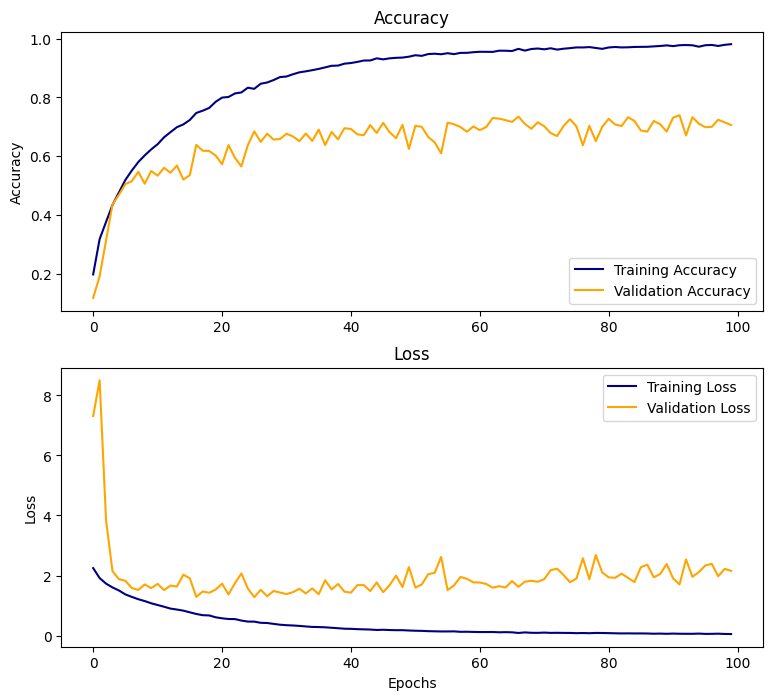

In [ ]:
plot_history(hist_3_layer)

In [ ]:
loss_cnn1, acc_cnn1 = CNN_3_layer_Max.evaluate(X_test, y_test)
print(f"Test Loss: {loss_cnn1}")
print(f"Test Accuracy: {acc_cnn1}")

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7307 - loss: 2.2207
Test Loss: 2.220747709274292
Test Accuracy: 0.7306666374206543


The graphs above show that the model is overfitting to the training data. Even though the accuracy and loss of the training data improves, the val accuracy and loss remains constant after only a few training epochs. This means that the model is memorizing the training data instead of recognizing general real world characteristics of the different genres.

In [ ]:
# Add L2 Regularization to Model to combat overfitting

# Define the L2 strength
l2_strength = 0.001

# Model Version Two - Updated with L2 Regularization
CNN_2_input = layers.Input(shape=input_shape, name="Mel_Spec")

# Layer One
x = layers.Conv2D(32, kernel_size=(3, 3), activation="relu",
                  kernel_regularizer=regularizers.l2(l2_strength))(CNN_2_input)
x = layers.BatchNormalization()(x)
x = layers.MaxPool2D(pool_size=(2, 2))(x)
x = layers.Dropout(0.2)(x)

# Layer Two
x = layers.Conv2D(64, kernel_size=(3,3), activation="relu",
                  kernel_regularizer=regularizers.l2(l2_strength))(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPool2D(pool_size=(2, 2))(x)
x = layers.Dropout(0.2)(x)

# Layer Three
x = layers.Conv2D(64, kernel_size=(3,3), activation="relu",
                  kernel_regularizer=regularizers.l2(l2_strength))(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPool2D(pool_size=(2, 2))(x)
x = layers.Dropout(0.2)(x)

# Flatten out to send through dense layers
x = layers.Flatten()(x)

# Dense Hidden Layer
x = layers.Dense(128, activation="relu",
                 kernel_regularizer=regularizers.l2(l2_strength))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

# Final classification
CNN_2_output = layers.Dense(10, activation="softmax", name="Output")(x)

CNN_2 = keras.Model(CNN_2_input, CNN_2_output, name='CNN_2')
CNN_2.summary()

Model: "CNN_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Mel_Spec (InputLayer)           │ (None, 128, 130, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 62, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 62, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 29, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,663,946 (6.35 MB)

 Trainable params: 1,663,370 (6.35 MB)

 Non-trainable params: 576 (2.25 KB)

In [ ]:
# Compile model for training
CNN_2.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [ ]:
# Train Model
hist_2 = CNN_2.fit(
    X_train,
    y_train,
    epochs = 100,
    validation_data=(X_val, y_val),
    verbose=1,
)

Epoch 1/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 21s 56ms/step - accuracy: 0.3314 - loss: 2.5664 - val_accuracy: 0.1564 - val_loss: 9.8103
Epoch 2/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.4832 - loss: 1.9309 - val_accuracy: 0.1076 - val_loss: 14.4846
Epoch 3/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.5653 - loss: 1.6710 - val_accuracy: 0.2634 - val_loss: 4.4795
Epoch 4/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.6143 - loss: 1.5230 - val_accuracy: 0.3844 - val_loss: 3.1653
Epoch 5/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.6437 - loss: 1.4003 - val_accuracy: 0.4779 - val_loss: 2.5030
Epoch 6/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.6798 - loss: 1.3033 - val_accuracy: 0.4713 - val_loss: 2.5989
Epoch 7/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.7021 - loss: 1.2249 - val_accuracy: 0.4699 - val_loss: 2.4685
Epoch 8/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.7219 - loss: 1.1662 

In [ ]:
loss_cnn2, acc_cnn2 = CNN_2.evaluate(X_test, y_test)
print(f"Test Loss: {loss_cnn1}")
print(f"Test Accuracy: {acc_cnn1}")

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7080 - loss: 1.8503
Test Loss: 2.220747709274292
Test Accuracy: 0.7306666374206543


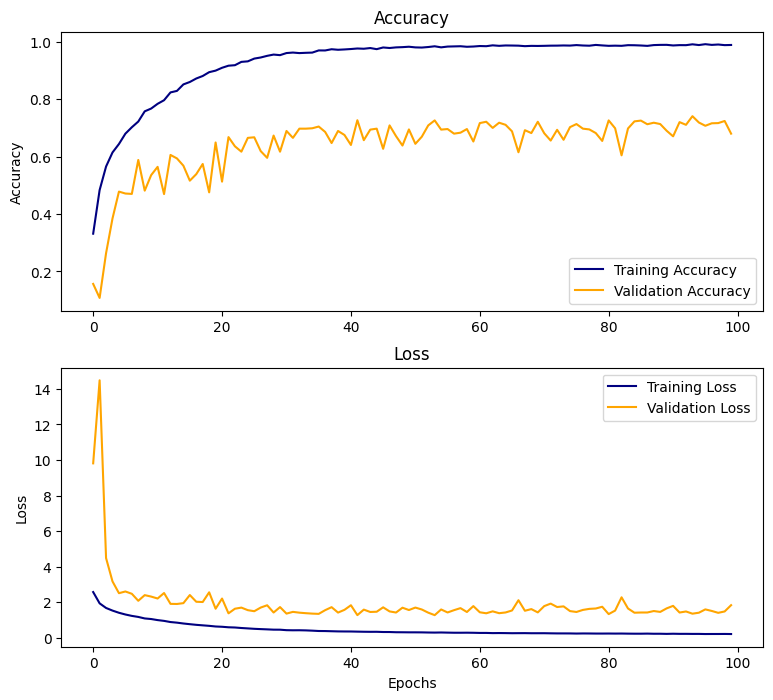

In [ ]:
plot_history(hist_2)

In [ ]:
# Add Image Augmentation to fight overfitting

# Define the L2 strength
l2_strength = 0.001

# Model Version Three - Updated with Data Augmentation
CNN_3_input = layers.Input(shape=input_shape, name="Mel_Spec")

# Add the preprocessing layers here
x = preprocessing_layers(CNN_3_input)

# Layer One
x = layers.Conv2D(32, kernel_size=(3, 3), activation="relu",
                  kernel_regularizer=regularizers.l2(l2_strength))(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPool2D(pool_size=(2, 2))(x)
x = layers.Dropout(0.2)(x)

# Layer Two
x = layers.Conv2D(64, kernel_size=(3,3), activation="relu",
                  kernel_regularizer=regularizers.l2(l2_strength))(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPool2D(pool_size=(2, 2))(x)
x = layers.Dropout(0.2)(x)

# Layer Three
x = layers.Conv2D(64, kernel_size=(3,3), activation="relu",
                  kernel_regularizer=regularizers.l2(l2_strength))(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPool2D(pool_size=(2, 2))(x)
x = layers.Dropout(0.2)(x)

# Flatten out to send through dense layers
x = layers.Flatten()(x)

# Dense Hidden Layer
x = layers.Dense(128, activation="relu",
                 kernel_regularizer=regularizers.l2(l2_strength))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

# Final classification
CNN_3_output = layers.Dense(10, activation="softmax", name="Output")(x)

CNN_3 = keras.Model(CNN_3_input, CNN_3_output, name='CNN_3')
CNN_3.summary()

Model: "CNN_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Mel_Spec (InputLayer)           │ (None, 128, 130, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 128, 130, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 62, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 62, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 29, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,663,946 (6.35 MB)

 Trainable params: 1,663,370 (6.35 MB)

 Non-trainable params: 576 (2.25 KB)

In [ ]:
# Compile new model with data augmentation

CNN_3.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy',
             tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3),
            ]
)

In [ ]:
# Train Model 3
# Create an instance of the SaveMetricsCallback for CNN_3
save_metrics_callback_cnn3 = SaveMetricsCallback(
    filename='CNN_Music_Logs/cnn3_metrics.json')

hist_3 = CNN_3.fit(
    X_train,
    y_train,
    epochs=100,
    validation_data=(X_val, y_val),
    verbose=1,
    callbacks=[save_metrics_callback_cnn3, early_stopping, checkpoint]
)

Epoch 1/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.2185 - loss: 3.2290 - sparse_top_k_categorical_accuracy: 0.4887
Epoch 1: val_loss improved from None to 7.89819, saving model to CNN_Music_Logs/best_model.keras

Epoch 1: finished saving model to CNN_Music_Logs/best_model.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - accuracy: 0.2751 - loss: 2.8480 - sparse_top_k_categorical_accuracy: 0.5663 - val_accuracy: 0.1003 - val_loss: 7.8982 - val_sparse_top_k_categorical_accuracy: 0.3061
Epoch 2/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.3804 - loss: 2.2665 - sparse_top_k_categorical_accuracy: 0.7043
Epoch 2: val_loss did not improve from 7.89819
219/219 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - accuracy: 0.3913 - loss: 2.2533 - sparse_top_k_categorical_accuracy: 0.7096 - val_accuracy: 0.1791 - val_loss: 11.6071 - val_sparse_top_k_categorical_accuracy: 0.3810
Epoch 3/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.4362 - loss: 2.0749 - sparse_top_k

In [ ]:
loss_cnn3, acc_cnn3, _ = CNN_3.evaluate(X_test, y_test)
print(f"Test Loss: {loss_cnn3}")
print(f"Test Accuracy: {acc_cnn3}")

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7113 - loss: 1.3988 - sparse_top_k_categorical_accuracy: 0.9180
Test Loss: 1.398768663406372
Test Accuracy: 0.7113333344459534


In [ ]:
# Recompile with smaller learning rate

CNN_3.compile(
    optimizer=optimizers.Adam(learning_rate=0.00001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy',
             tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3),
            ]
)

In [ ]:
hist_3_low_LR = CNN_3.fit(
    X_train,
    y_train,
    epochs=100,
    validation_data=(X_val, y_val),
    verbose=1,
    callbacks=[save_metrics_callback_cnn3, early_stopping, checkpoint]
)

Epoch 1/100
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9028 - loss: 0.5290 - sparse_top_k_categorical_accuracy: 0.9909
Epoch 1: val_loss did not improve from 1.30658
219/219 ━━━━━━━━━━━━━━━━━━━━ 14s 49ms/step - accuracy: 0.9036 - loss: 0.5254 - sparse_top_k_categorical_accuracy: 0.9916 - val_accuracy: 0.6985 - val_loss: 1.4119 - val_sparse_top_k_categorical_accuracy: 0.9432
Epoch 2/100
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9005 - loss: 0.5370 - sparse_top_k_categorical_accuracy: 0.9873
Epoch 2: val_loss did not improve from 1.30658
219/219 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - accuracy: 0.9032 - loss: 0.5277 - sparse_top_k_categorical_accuracy: 0.9890 - val_accuracy: 0.7025 - val_loss: 1.4107 - val_sparse_top_k_categorical_accuracy: 0.9412
Epoch 3/100
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8994 - loss: 0.5346 - sparse_top_k_categorical_accuracy: 0.9898
Epoch 3: val_loss did not improve from 1.30658
219/219 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/ste

In [ ]:
l2_strength = 0.001

CNN_4_input = layers.Input(shape=input_shape, name="Mel_Spec")
x = preprocessing_layers(CNN_4_input)

# Block 1
x = layers.Conv2D(32, (3, 3), padding="same",
                  kernel_regularizer=regularizers.l2(l2_strength))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("elu")(x)
x = layers.MaxPool2D(pool_size=(2, 2))(x)
x = layers.Dropout(0.2)(x)

# Block 2
x = layers.Conv2D(64, (3, 3), padding="same",
                  kernel_regularizer=regularizers.l2(l2_strength))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("elu")(x)
x = layers.MaxPool2D(pool_size=(2, 2))(x)
x = layers.Dropout(0.2)(x)

# Block 3 - Added more filters to capture complex genre textures
x = layers.Conv2D(128, (3, 3), padding="same",
                  kernel_regularizer=regularizers.l2(l2_strength))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("elu")(x)
x = layers.MaxPool2D(pool_size=(2, 2))(x)
x = layers.Dropout(0.3)(x)

# Block 4 - Deep feature extraction
x = layers.Conv2D(128, (3, 3), padding="same",
                  kernel_regularizer=regularizers.l2(l2_strength))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("elu")(x)

# 2. GLOBAL AVERAGE POOLING
x = layers.GlobalAveragePooling2D()(x)

# Dense Layers
x = layers.Dense(256, kernel_regularizer=regularizers.l2(l2_strength))(x)
x = layers.Activation("elu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

CNN_4_output = layers.Dense(10, activation="softmax", name="Output")(x)

CNN_4 = models.Model(CNN_4_input, CNN_4_output, name='CNN_4')


CNN_4.summary()

Model: "CNN_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Mel_Spec (InputLayer)           │ (None, 128, 130, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Audio_Preprocessing             │ (None, 128, 130, 1)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 128, 130, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128, 130, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 128, 130, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 65, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64, 65, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 64, 65, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,02

 Total params: 278,282 (1.06 MB)

 Trainable params: 277,066 (1.06 MB)

 Non-trainable params: 1,216 (4.75 KB)

In [ ]:
CNN_4.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy',
             tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3),
            ]
)

In [ ]:
# Train Model 4
# Create an instance of the SaveMetricsCallback for CNN_4
save_metrics_callback_cnn4 = SaveMetricsCallback(
    filename='CNN_Music_Logs/cnn4_metrics.json')

hist_4 = CNN_4.fit(
    X_train,
    y_train,
    epochs=100,
    validation_data=(X_val, y_val),
    verbose=1,
    callbacks=[save_metrics_callback_cnn4,
               early_stopping,
               checkpoint,
               lr_scheduler]
)

Epoch 1/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.2470 - loss: 2.9249 - sparse_top_k_categorical_accuracy: 0.5235
Epoch 1: val_loss did not improve from 1.30658
219/219 ━━━━━━━━━━━━━━━━━━━━ 18s 63ms/step - accuracy: 0.2911 - loss: 2.6989 - sparse_top_k_categorical_accuracy: 0.6006 - val_accuracy: 0.1618 - val_loss: 3.2164 - val_sparse_top_k_categorical_accuracy: 0.3556 - learning_rate: 1.0000e-04
Epoch 2/100
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.3800 - loss: 2.3875 - sparse_top_k_categorical_accuracy: 0.6889
Epoch 2: val_loss did not improve from 1.30658
219/219 ━━━━━━━━━━━━━━━━━━━━ 13s 59ms/step - accuracy: 0.3813 - loss: 2.3597 - sparse_top_k_categorical_accuracy: 0.7036 - val_accuracy: 0.1524 - val_loss: 3.6021 - val_sparse_top_k_categorical_accuracy: 0.4492 - learning_rate: 1.0000e-04
Epoch 3/100
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.4363 - loss: 2.1681 - sparse_top_k_categorical_accuracy: 0.7598
Epoch 3: val_loss did not improv

In [ ]:
def multi_scale_block(x, filters, l2_strength):
    """
    Bottlenecked Inception-style block.
    """
    b = filters // 4  # branch width
    a = layers.Conv2D(b, (1, 1), padding="same",
                      kernel_regularizer=regularizers.l2(l2_strength))(x)
    b_ = layers.Conv2D(b, (3, 3), padding="same",
                       kernel_regularizer=regularizers.l2(l2_strength))(x)
    c = layers.Conv2D(b, (1, 7), padding="same",
                      kernel_regularizer=regularizers.l2(l2_strength))(x)  # temporal
    d = layers.Conv2D(b, (7, 1), padding="same",
                      kernel_regularizer=regularizers.l2(l2_strength))(x)  # spectral
    x = layers.Concatenate()([a, b_, c, d])   # exactly `filters` channels
    x = layers.BatchNormalization()(x)
    x = layers.Activation("elu")(x)
    return x


def se_block(x, ratio=8):
    filters = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(max(filters // ratio, 4), activation="elu")(se)
    se = layers.Dense(filters, activation="sigmoid")(se)
    se = layers.Reshape((1, 1, filters))(se)
    return layers.Multiply()([x, se])


def residual_block(x, filters, l2_strength):
    shortcut = layers.Conv2D(filters, (1, 1), padding="same",
                             kernel_regularizer=regularizers.l2(l2_strength))(x)
    x = layers.Conv2D(filters, (3, 3), padding="same",
                      kernel_regularizer=regularizers.l2(l2_strength))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("elu")(x)
    x = layers.Conv2D(filters, (3, 3), padding="same",
                      kernel_regularizer=regularizers.l2(l2_strength))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Add()([x, shortcut])
    return layers.Activation("elu")(x)


def strided_downsample(x, filters, l2_strength):
    x = layers.Conv2D(filters, (3, 3), strides=(2, 2), padding="same",
                      kernel_regularizer=regularizers.l2(l2_strength))(x)
    x = layers.BatchNormalization()(x)
    return layers.Activation("elu")(x)


In [ ]:
l2_strength = 0.001

CNN_5_input = layers.Input(shape=input_shape, name="Mel_Spec")
x = preprocessing_layers(CNN_5_input)
x = SpecAugment(freq_mask_param=15, time_mask_param=15)(x)

# Block 1 — 64 filters (bottlenecked, so 16 per branch → 64 out)
x = multi_scale_block(x, 64, l2_strength)
x = strided_downsample(x, 64, l2_strength)
x = layers.Dropout(0.2)(x)

# Block 2 — 128 filters
x = multi_scale_block(x, 128, l2_strength)
x = strided_downsample(x, 128, l2_strength)
x = layers.Dropout(0.2)(x)

# Block 3 — residual + SE, 128 filters
x = residual_block(x, 128, l2_strength)
x = se_block(x, ratio=8)
x = layers.MaxPool2D(pool_size=(2, 2))(x)
x = layers.Dropout(0.3)(x)

# Block 4 — residual + SE, 128 filters (was 256 — biggest param saving)
x = residual_block(x, 128, l2_strength)
x = se_block(x, ratio=8)
x = layers.Dropout(0.3)(x)

# Pooling head
gap = layers.GlobalAveragePooling2D()(x)
gmp = layers.GlobalMaxPooling2D()(x)
x = layers.Concatenate()([gap, gmp])             # 256-dim

# Classifier — 128 instead of 256 (halved)
x = layers.Dense(128, kernel_regularizer=regularizers.l2(l2_strength))(x)
x = layers.Activation("elu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

CNN_5_output = layers.Dense(10, activation="softmax", name="Output")(x)

CNN_5 = models.Model(CNN_5_input, CNN_5_output, name="CNN_5")
CNN_5.summary()

Model: "CNN_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Mel_Spec            │ (None, 128, 130,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Audio_Preprocessing │ (None, 128, 130,  │          0 │ Mel_Spec[0][0]    │
│ (Sequential)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spec_augment        │ (None, 128, 130,  │          0 │ Audio_Preprocess… │
│ (SpecAugment)       │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_43 (Conv2D)  │ (None, 128, 130,  │         32 │ spec_augment[0][… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_44 (Conv2D)  │ (None, 128, 130,  │        160 │ spec_augment[0][… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_45 (Conv2D)  │ (None, 128, 130,  │        128 │ spec_augment[0][… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_46 (Conv2D)  │ (None, 128, 130,  │        128 │ spec_augment[0][… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 128, 130,  │          0 │ conv2d_43[0][0],  │
│ (Concatenate)       │ 64)               │            │ conv2d_44[0][0],  │
│                     │                   │            │ conv2d_45[0][0],  │
│                     │                   │            │ conv2d_46[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 130,  │        256 │ concatenate_6[0]… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_28       │ (None, 128, 130,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_47 (Conv2D)  │ (None, 64, 65,    │     36,928 │ activation_28[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 65,    │        256 │ conv2d_47[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_29       │ (None, 64, 65,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_22          │ (None, 64, 65,    │          0 │ activation_29[0]… │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_48 (Conv2D)  │ (None, 64, 65,    │      2,080 │ dropout_22[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_49 (Conv2D)  │ (None, 64, 65,    │     18,464 │ dropout_22[0][0]  │
│                     │ 32)               │            │                 

 Total params: 904,362 (3.45 MB)

 Trainable params: 902,314 (3.44 MB)

 Non-trainable params: 2,048 (8.00 KB)

In [ ]:
CNN_5.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy',
             tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3),
            ]
)

In [ ]:
# Train Model 5
# Create an instance of the SaveMetricsCallback for CNN_5
save_metrics_callback_cnn5 = SaveMetricsCallback(
    filename='CNN_Music_Logs/cnn5_metrics.json')

hist_5 = CNN_5.fit(
    X_train,
    y_train,
    epochs=100,
    validation_data=(X_val, y_val),
    verbose=1,
    callbacks=[save_metrics_callback_cnn5,
               early_stopping,
               checkpoint,
               lr_scheduler]
)

Epoch 1/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.2465 - loss: 3.7628 - sparse_top_k_categorical_accuracy: 0.5515
Epoch 1: val_loss did not improve from 1.30658
219/219 ━━━━━━━━━━━━━━━━━━━━ 57s 206ms/step - accuracy: 0.3151 - loss: 3.3968 - sparse_top_k_categorical_accuracy: 0.6416 - val_accuracy: 0.0996 - val_loss: 9.8120 - val_sparse_top_k_categorical_accuracy: 0.2975 - learning_rate: 0.0010
Epoch 2/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.4606 - loss: 2.8097 - sparse_top_k_categorical_accuracy: 0.7863
Epoch 2: val_loss did not improve from 1.30658
219/219 ━━━━━━━━━━━━━━━━━━━━ 40s 182ms/step - accuracy: 0.4762 - loss: 2.7519 - sparse_top_k_categorical_accuracy: 0.7957 - val_accuracy: 0.1016 - val_loss: 9.0585 - val_sparse_top_k_categorical_accuracy: 0.4031 - learning_rate: 0.0010
Epoch 3/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.5362 - loss: 2.5311 - sparse_top_k_categorical_accuracy: 0.8342
Epoch 3: val_loss did not improve f

In [ ]:
l2_strength = 0.001

CNN_6_input = layers.Input(shape=input_shape, name="Mel_Spec")
x = preprocessing_layers(CNN_6_input)
x = SpecAugment(freq_mask_param=15, time_mask_param=15)(x)

# Block 1 — same as your original
x = layers.Conv2D(32, (3, 3), padding="same",
                  kernel_regularizer=regularizers.l2(l2_strength))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("elu")(x)
x = layers.MaxPool2D(pool_size=(2, 2))(x)
x = layers.Dropout(0.25)(x)

# Block 2
x = layers.Conv2D(64, (3, 3), padding="same",
                  kernel_regularizer=regularizers.l2(l2_strength))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("elu")(x)
x = layers.MaxPool2D(pool_size=(2, 2))(x)
x = layers.Dropout(0.25)(x)

# Block 3
x = layers.Conv2D(128, (3, 3), padding="same",
                  kernel_regularizer=regularizers.l2(l2_strength))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("elu")(x)
x = layers.MaxPool2D(pool_size=(2, 2))(x)
x = layers.Dropout(0.35)(x)

# Block 4 — kept at 128, no increase
x = layers.Conv2D(128, (3, 3), padding="same",
                  kernel_regularizer=regularizers.l2(l2_strength))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("elu")(x)
x = layers.Dropout(0.35)(x)

# GAP + GMP — zero parameters, small but consistent win
gap = layers.GlobalAveragePooling2D()(x)
gmp = layers.GlobalMaxPooling2D()(x)
x = layers.Concatenate()([gap, gmp])

# Smaller dense head than CNN_4 — 128 not 256
x = layers.Dense(128, kernel_regularizer=regularizers.l2(l2_strength))(x)
x = layers.Activation("elu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

CNN_6_output = layers.Dense(10, activation="softmax", name="Output")(x)
CNN_6 = models.Model(CNN_6_input, CNN_6_output, name="CNN_6")

CNN_6.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy",
             tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2)]
)

In [ ]:
# Train Model
# Create an instance of the SaveMetricsCallback for CNN_5

save_metrics_callback_cnn6 = SaveMetricsCallback(
    filename='CNN_Music_Logs/cnn6_metrics.json')

# Recompile CNN_6 with SparseCategoricalCrossentropy to match y_train/y_val format
CNN_6.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy",
             tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2)]
)

hist_6 = CNN_6.fit(
    X_train,
    y_train,
    epochs=100,
    validation_data=(X_val, y_val),
    verbose=1,
    callbacks=[save_metrics_callback_cnn6,
               early_stopping,
               checkpoint,
               lr_scheduler]
)

Epoch 1/100
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.2129 - loss: 2.9428 - sparse_top_k_categorical_accuracy: 0.3624
Epoch 1: val_loss did not improve from 1.30658
219/219 ━━━━━━━━━━━━━━━━━━━━ 22s 68ms/step - accuracy: 0.2743 - loss: 2.5994 - sparse_top_k_categorical_accuracy: 0.4450 - val_accuracy: 0.0996 - val_loss: 12.7917 - val_sparse_top_k_categorical_accuracy: 0.1999 - learning_rate: 0.0010
Epoch 2/100
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.3780 - loss: 2.1537 - sparse_top_k_categorical_accuracy: 0.5808
Epoch 2: val_loss did not improve from 1.30658
219/219 ━━━━━━━━━━━━━━━━━━━━ 13s 60ms/step - accuracy: 0.4044 - loss: 2.0710 - sparse_top_k_categorical_accuracy: 0.6106 - val_accuracy: 0.0996 - val_loss: 18.6757 - val_sparse_top_k_categorical_accuracy: 0.1999 - learning_rate: 0.0010
Epoch 3/100
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.4547 - loss: 1.8966 - sparse_top_k_categorical_accuracy: 0.6721
Epoch 3: val_loss did not improve from